In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import os, time
print("importation done")

importation done


In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

COLORS = {
    "primary":   "#2E75B6",
    "secondary": "#ED7D31",
    "success":   "#70AD47",
    "danger":    "#FF0000",
    "light":     "#D6E4F0",
    "dark":      "#1F3864",
    "churn":     "#E74C3C",
    "retain":    "#2ECC71",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)


### 2.0  Load dataset

In [3]:
import pandas as pd

FILE_PATH = "data/Telco-Customer-Churn.csv"

try:
    df_raw = pd.read_csv(FILE_PATH)
    print(f"\nDataset loaded {df_raw.shape[0]} rows and {df_raw.shape[1]} cols")

except Exception as e:
    print("dataset not loaded ", e)
    df_raw = None

df = df_raw.copy()


Dataset loaded 7043 rows and 21 cols


# CHAPTER 2 : DATA UNDERSTANDING & PREPARATION

### 2.1  Univariate analysis

In [4]:
print("\n" + "─" * 50)
print("  2.1 Univariate Analysis")
print("─" * 50)

#basic information
print("\n### Basic Info ###")
print(df.info())
print("\n### First 5 Rows ###")
print(df.head())
print("\n### Descriptive Statistics (Numerical) ###")
print(df.describe().round(2))


──────────────────────────────────────────────────
  2.1 Univariate Analysis
──────────────────────────────────────────────────

### Basic Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   


### Target Variable (Churn) Distribution ###
       Count  Percentage (%)
Churn                       
No      5174            73.5
Yes     1869            26.5


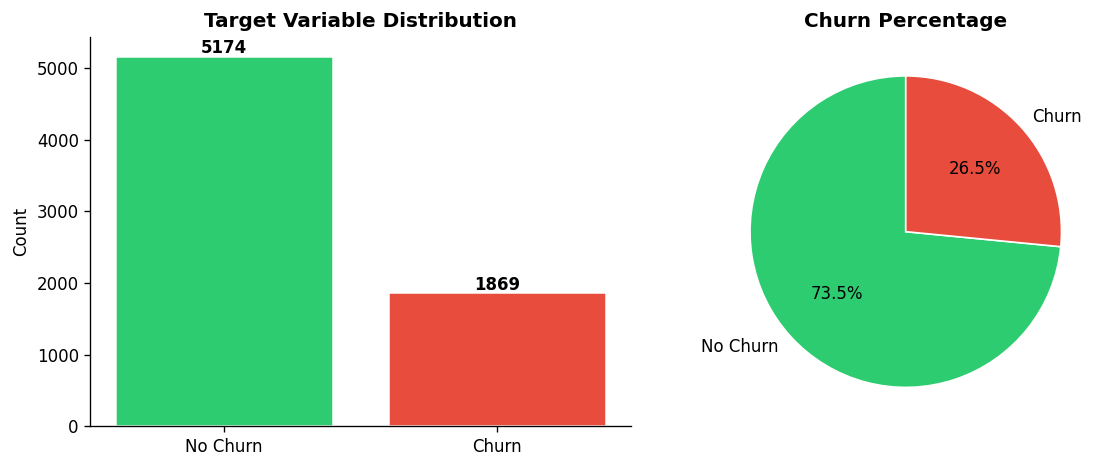

In [5]:
# --- Target distribution ---
churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100
print(f"\n### Target Variable (Churn) Distribution ###")
print(pd.DataFrame({"Count": churn_counts, "Percentage (%)": churn_pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["No Churn", "Churn"], churn_counts.values,
            color=[COLORS["retain"], COLORS["churn"]], edgecolor="white", linewidth=1.5)
axes[0].set_title("Target Variable Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(churn_counts.values, labels=["No Churn", "Churn"],
            colors=[COLORS["retain"], COLORS["churn"]],
            autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Churn Percentage", fontweight="bold")
plt.tight_layout()
plt.savefig("plots/01_target_distribution.png", bbox_inches="tight")
plt.show()

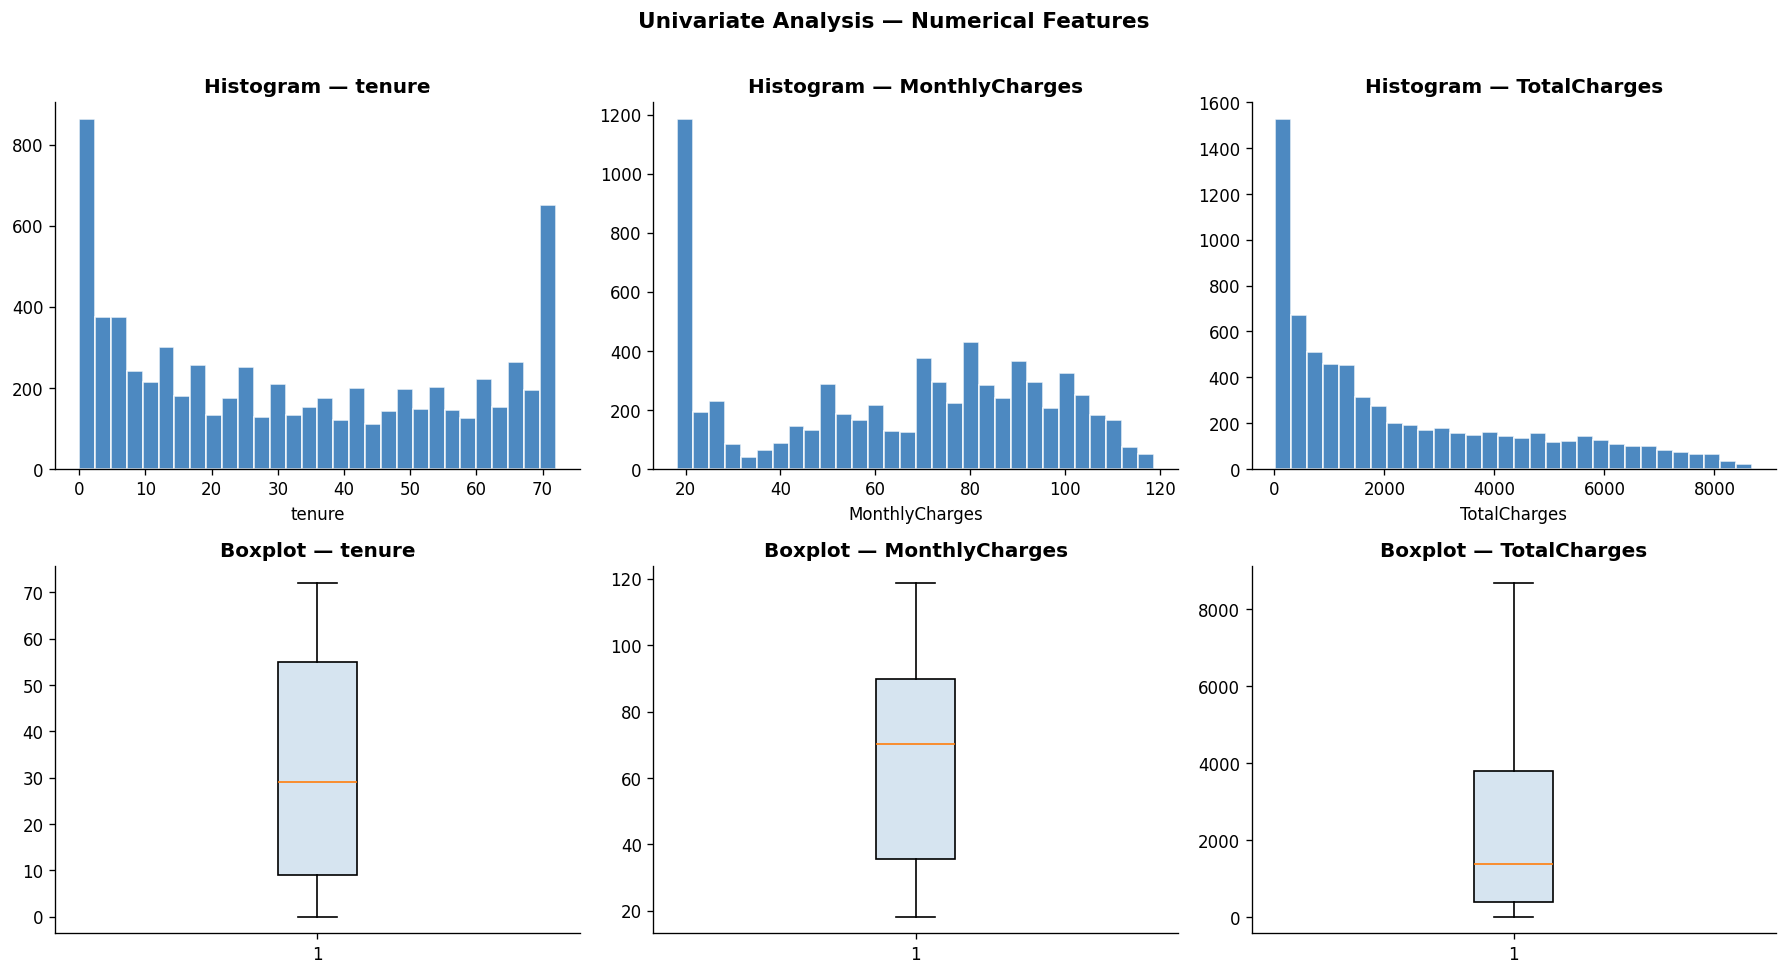

In [6]:
# --- Numerical features ---
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")  # fix mixed type

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col].dropna(), bins=30, color=COLORS["primary"], edgecolor="white", alpha=0.85)
    axes[0, i].set_title(f"Histogram — {col}", fontweight="bold")
    axes[0, i].set_xlabel(col)
    axes[1, i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor=COLORS["light"]))
    axes[1, i].set_title(f"Boxplot — {col}", fontweight="bold")
plt.suptitle("Univariate Analysis — Numerical Features", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/02_univariate_numerical.png", bbox_inches="tight")
plt.show()

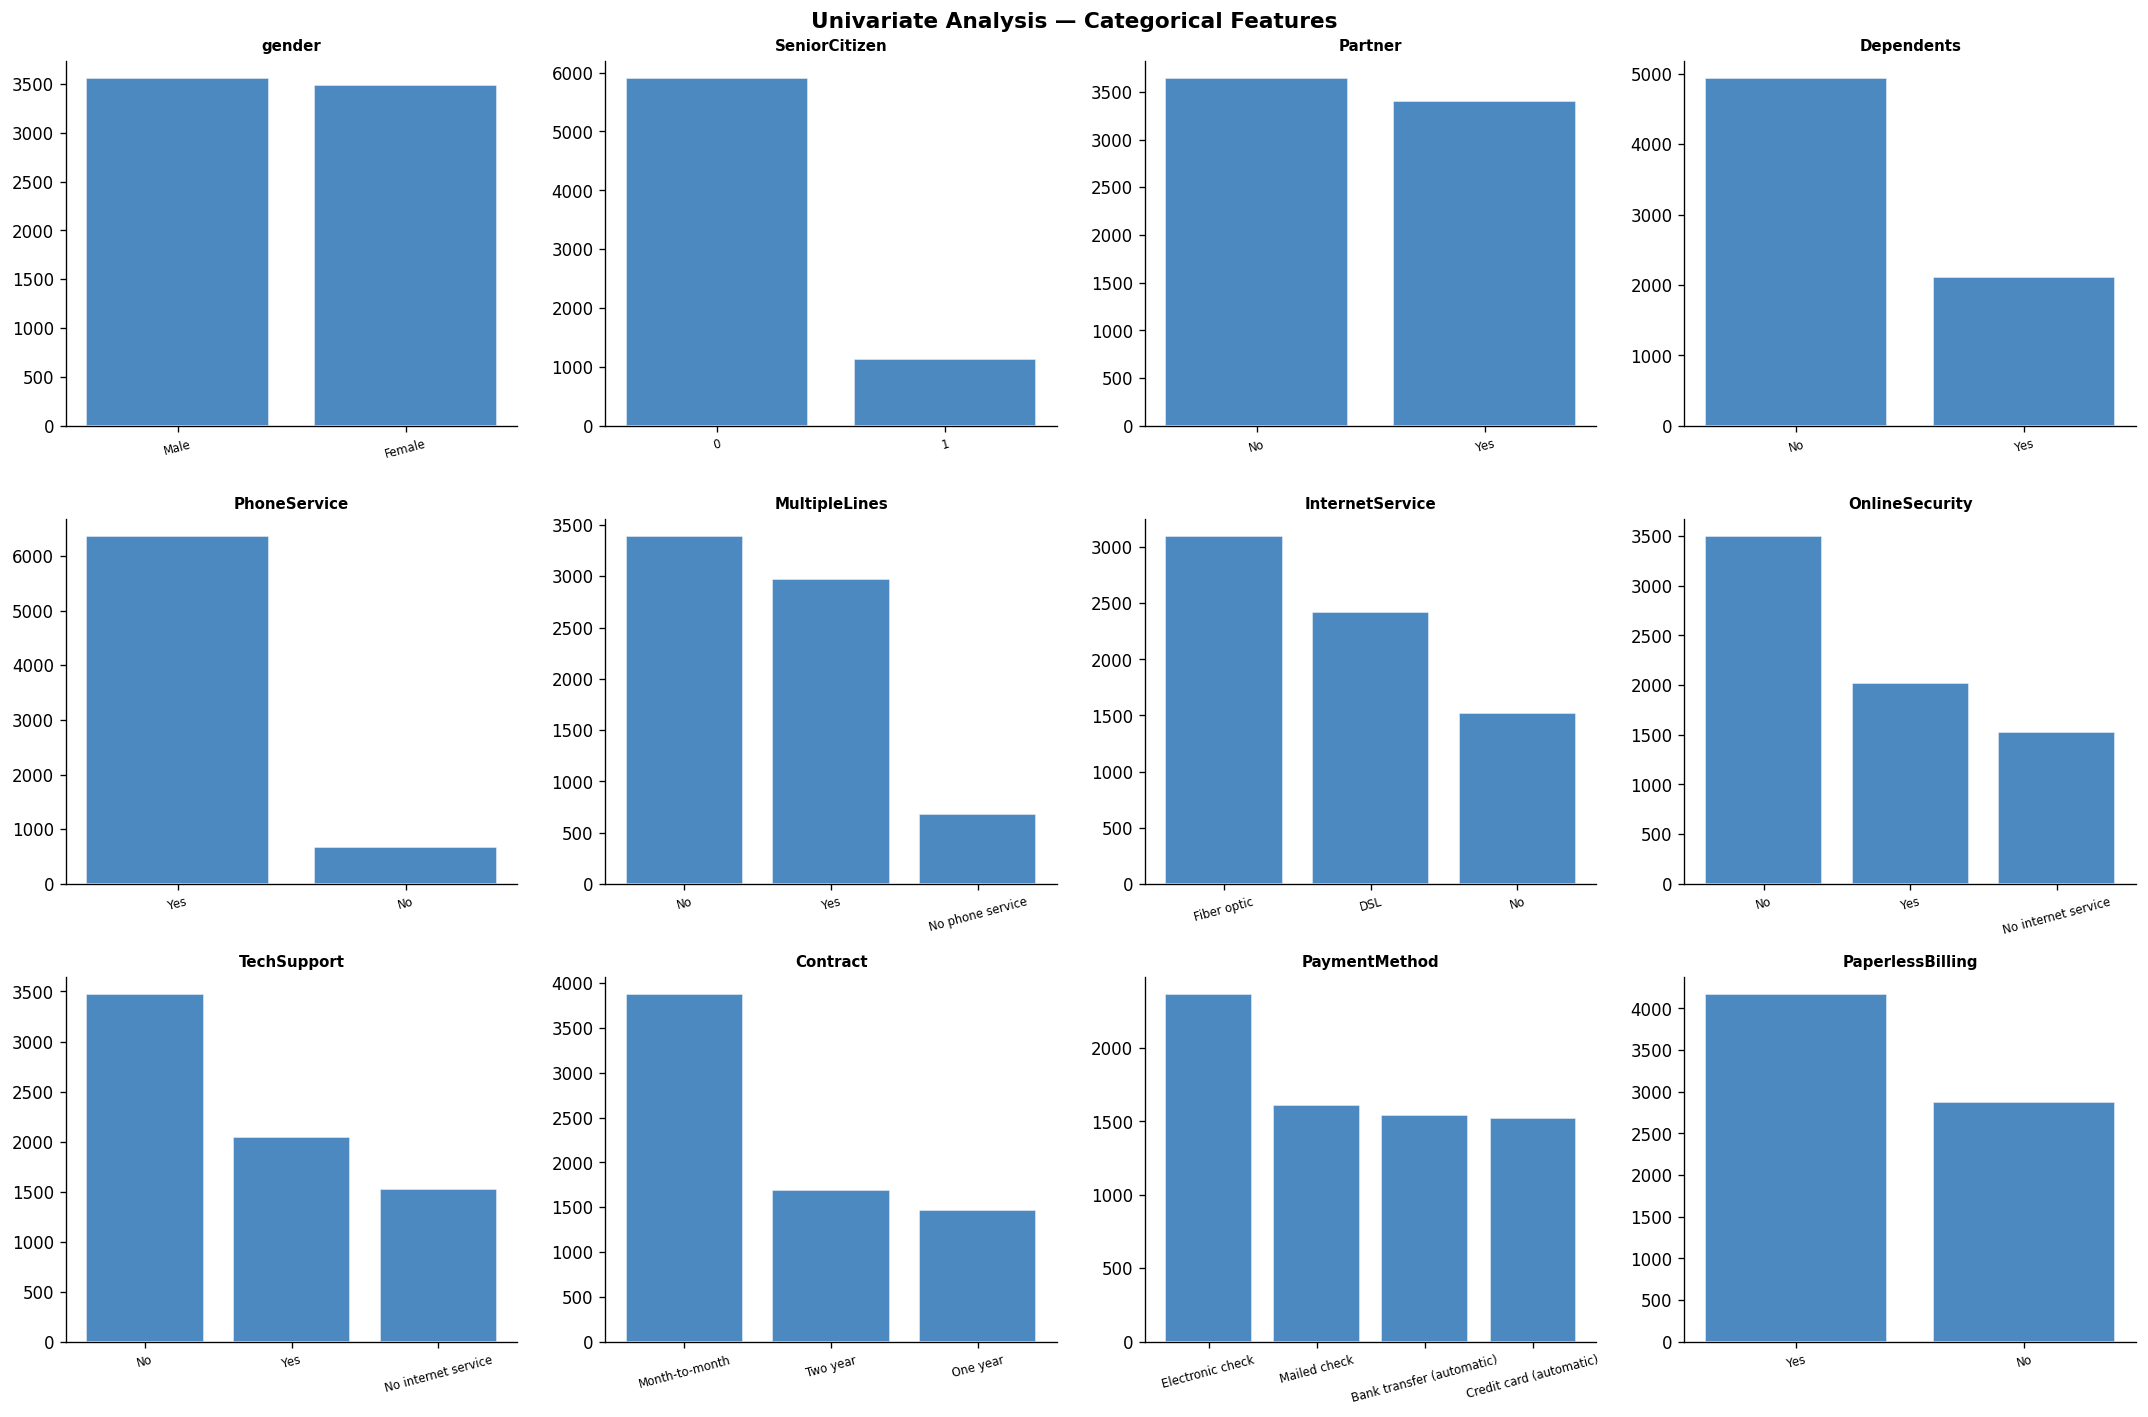

In [7]:
# --- Categorical features ---
cat_cols = ["gender", "SeniorCitizen", "Partner", "Dependents",
            "PhoneService", "MultipleLines", "InternetService",
            "OnlineSecurity", "TechSupport", "Contract",
            "PaymentMethod", "PaperlessBilling"]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values, color=COLORS["primary"], alpha=0.85, edgecolor="white")
    axes[i].set_title(col, fontweight="bold", fontsize=9)
    axes[i].tick_params(axis="x", rotation=15, labelsize=7)
plt.suptitle("Univariate Analysis — Categorical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/03_univariate_categorical.png", bbox_inches="tight")
plt.show()

### 2.2  BIVARIATE ANALYSIS


──────────────────────────────────────────────────
  2.2 BIVARIATE ANALYSIS
──────────────────────────────────────────────────


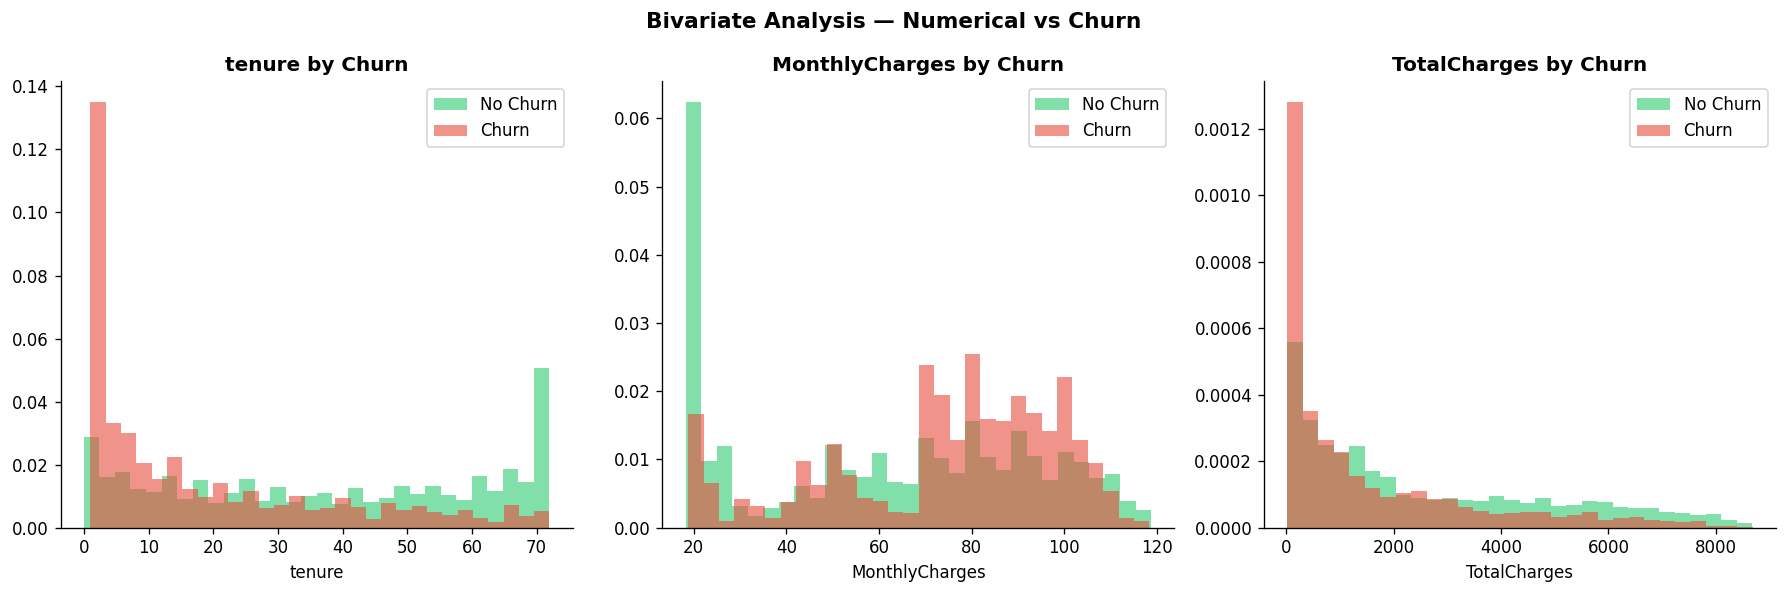

In [8]:
print("\n" + "─" * 50)
print("  2.2 BIVARIATE ANALYSIS")
print("─" * 50)

# Encode Churn for correlation
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

# --- Numerical vs Churn ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(num_cols):
    churn_yes = df[df["Churn"] == "Yes"][col].dropna()
    churn_no  = df[df["Churn"] == "No"][col].dropna()
    axes[i].hist(churn_no,  bins=30, alpha=0.6, color=COLORS["retain"], label="No Churn", density=True)
    axes[i].hist(churn_yes, bins=30, alpha=0.6, color=COLORS["churn"],  label="Churn",    density=True)
    axes[i].set_title(f"{col} by Churn", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].legend()
plt.suptitle("Bivariate Analysis — Numerical vs Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/04_bivariate_numerical_churn.png", bbox_inches="tight")
plt.show()

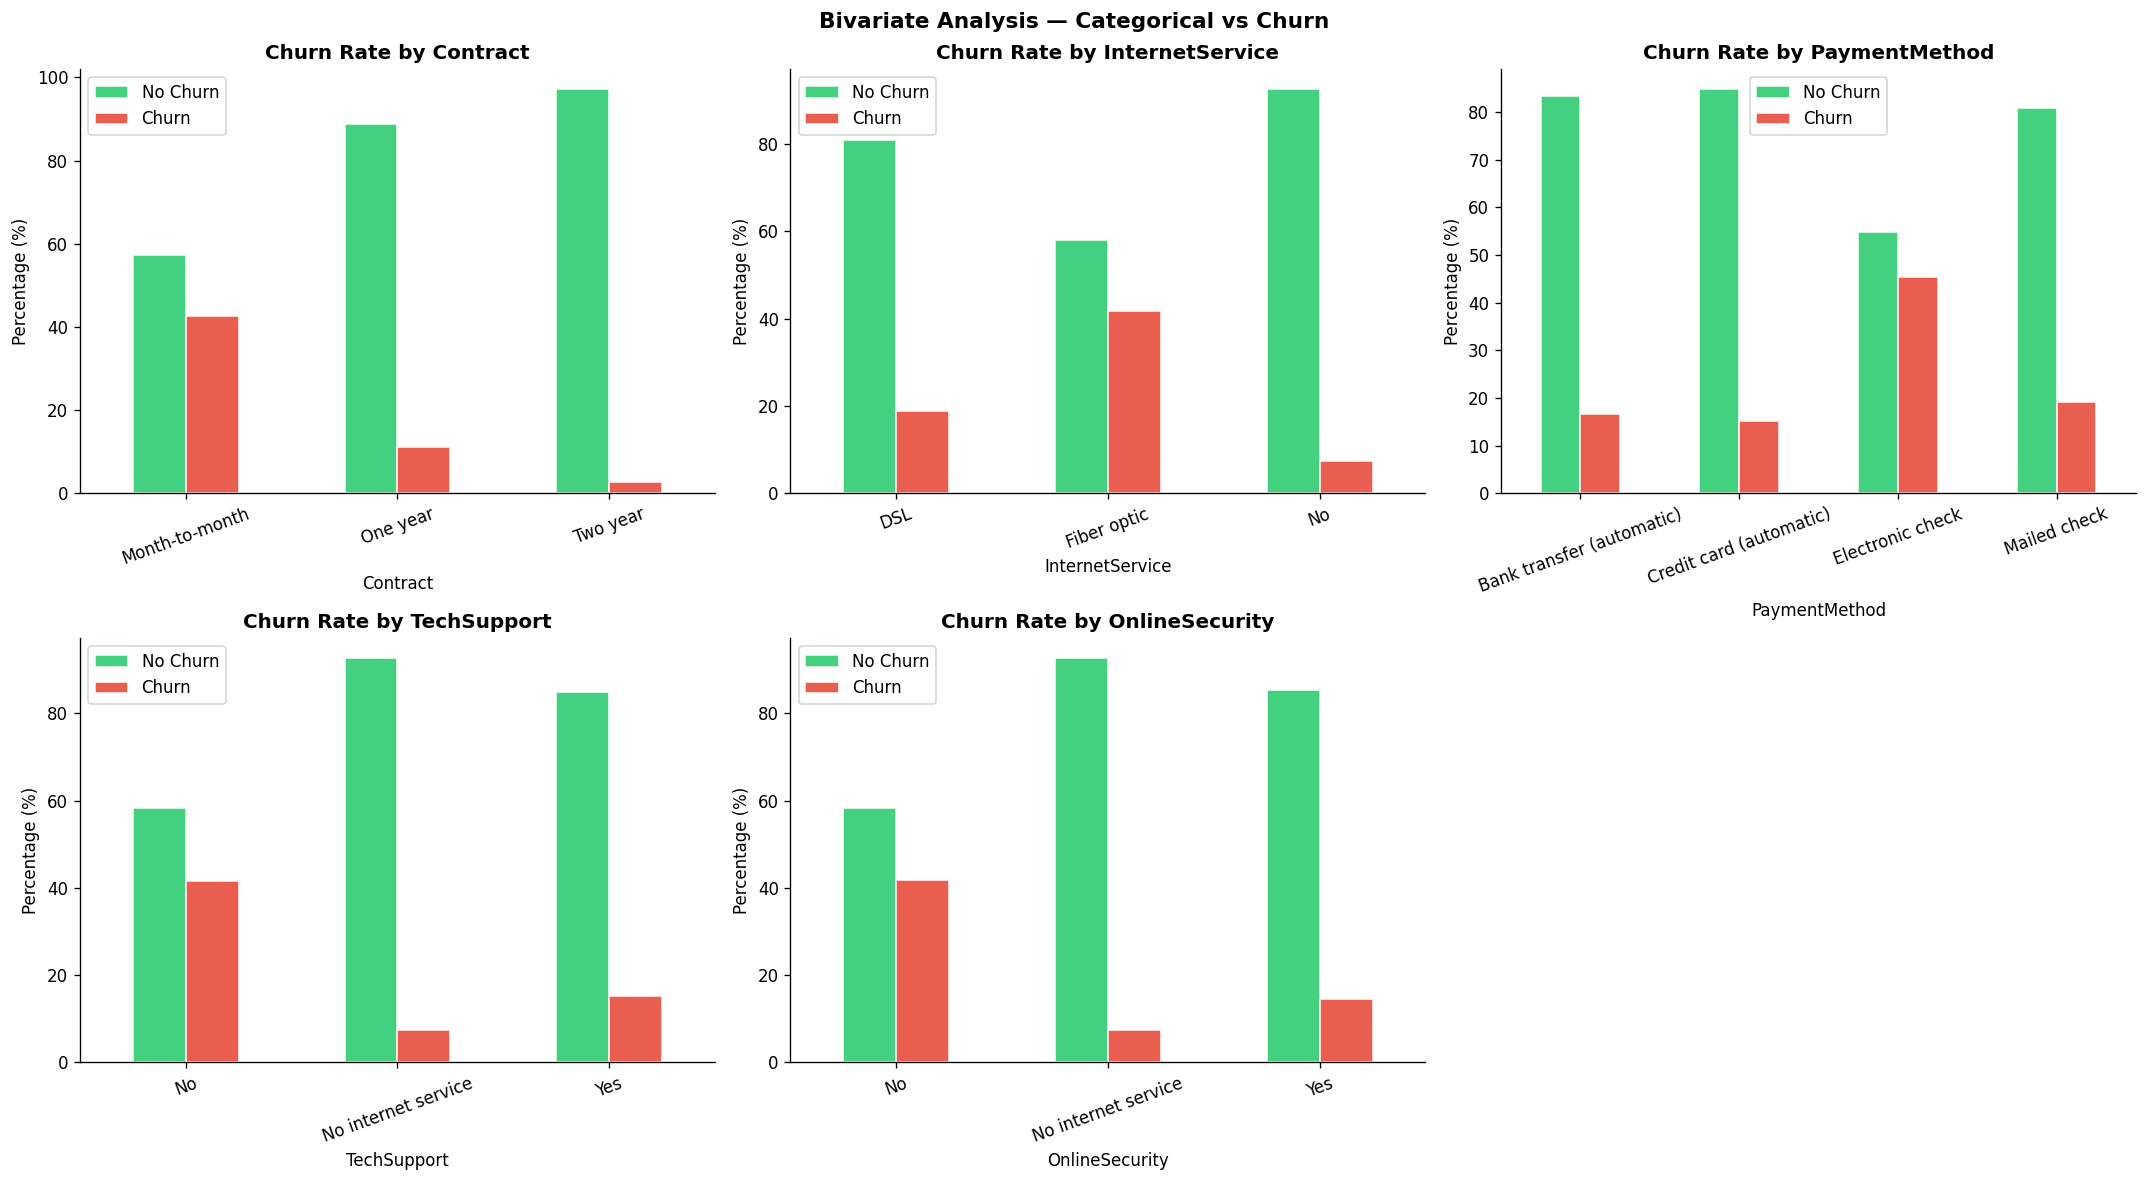

In [9]:
# --- Categorical vs Churn ---
key_cats = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(key_cats):
    ct = df.groupby([col, "Churn"]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind="bar", ax=axes[i], color=[COLORS["retain"], COLORS["churn"]],
                edgecolor="white", alpha=0.9)
    axes[i].set_title(f"Churn Rate by {col}", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis="x", rotation=20)
    axes[i].legend(["No Churn", "Churn"])
axes[-1].set_visible(False)
plt.suptitle("Bivariate Analysis — Categorical vs Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/05_bivariate_categorical_churn.png", bbox_inches="tight")
plt.show()

In [10]:
# --- Hypothesis Validation ---
print("\n### HYPOTHESIS VALIDATION ###")
h1 = df.groupby("Contract")["Churn_binary"].mean() * 100
h2 = df.groupby("InternetService")["Churn_binary"].mean() * 100
h3_corr = df[["MonthlyCharges", "Churn_binary"]].corr().iloc[0, 1]

print(f"\nH1 — Churn rate by Contract Type:\n{h1.round(1)}")
print(f"\nH2 — Churn rate by Internet Service:\n{h2.round(1)}")
print(f"\nH3 — Correlation(MonthlyCharges, Churn): {h3_corr:.4f}")



### HYPOTHESIS VALIDATION ###

H1 — Churn rate by Contract Type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn_binary, dtype: float64

H2 — Churn rate by Internet Service:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn_binary, dtype: float64

H3 — Correlation(MonthlyCharges, Churn): 0.1934


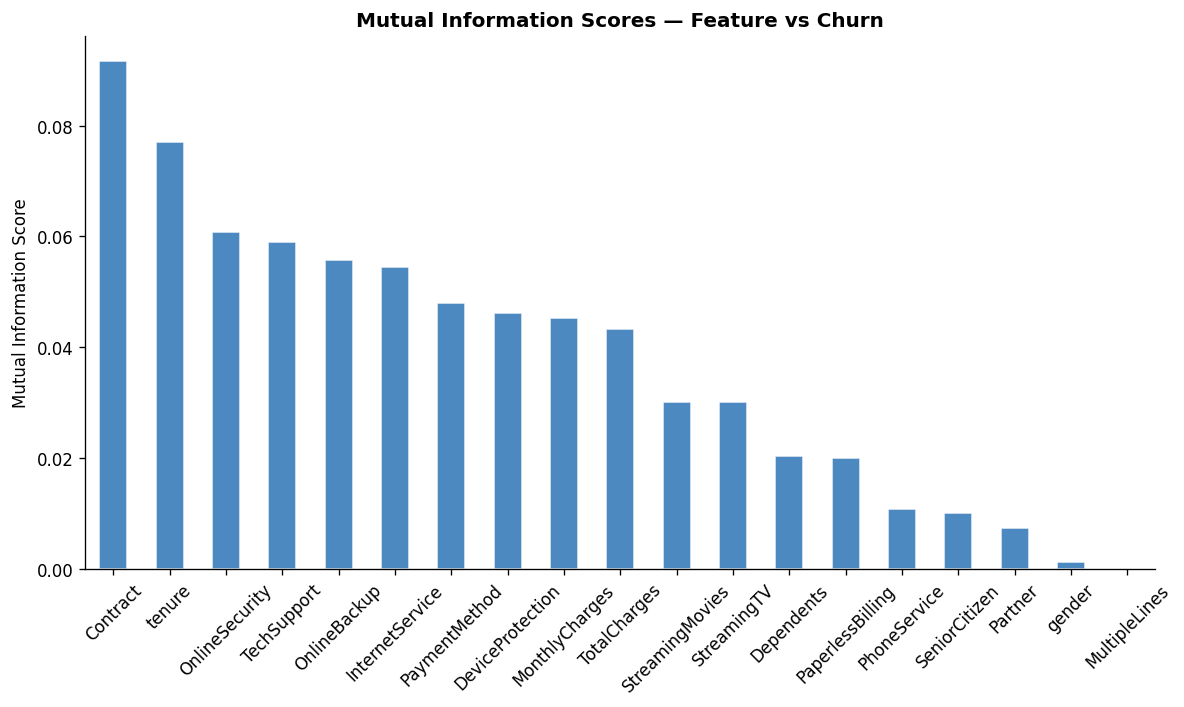


Top 10 Features by Mutual Information:
Contract            0.0916
tenure              0.0770
OnlineSecurity      0.0609
TechSupport         0.0591
OnlineBackup        0.0557
InternetService     0.0544
PaymentMethod       0.0479
DeviceProtection    0.0463
MonthlyCharges      0.0453
TotalCharges        0.0433
dtype: float64


In [11]:
# --- Mutual Information (bivariate) ---
df_mi = df.drop(columns=["customerID", "Churn", "Churn_binary"]).copy()
df_mi["TotalCharges"] = pd.to_numeric(df_mi["TotalCharges"], errors="coerce").fillna(0)
for c in df_mi.select_dtypes("object").columns:
    df_mi[c] = LabelEncoder().fit_transform(df_mi[c].astype(str))

mi_scores = mutual_info_classif(df_mi, df["Churn_binary"], random_state=RANDOM_STATE)
mi_df = pd.Series(mi_scores, index=df_mi.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
mi_df.plot(kind="bar", ax=ax, color=COLORS["primary"], edgecolor="white", alpha=0.85)
ax.set_title("Mutual Information Scores — Feature vs Churn", fontweight="bold")
ax.set_ylabel("Mutual Information Score")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("plots/06_mutual_information.png", bbox_inches="tight")
plt.show()
print("\nTop 10 Features by Mutual Information:")
print(mi_df.head(10).round(4))

### 2.3  MULTIVARIATE ANALYSIS


──────────────────────────────────────────────────
  2.3 MULTIVARIATE ANALYSIS
──────────────────────────────────────────────────


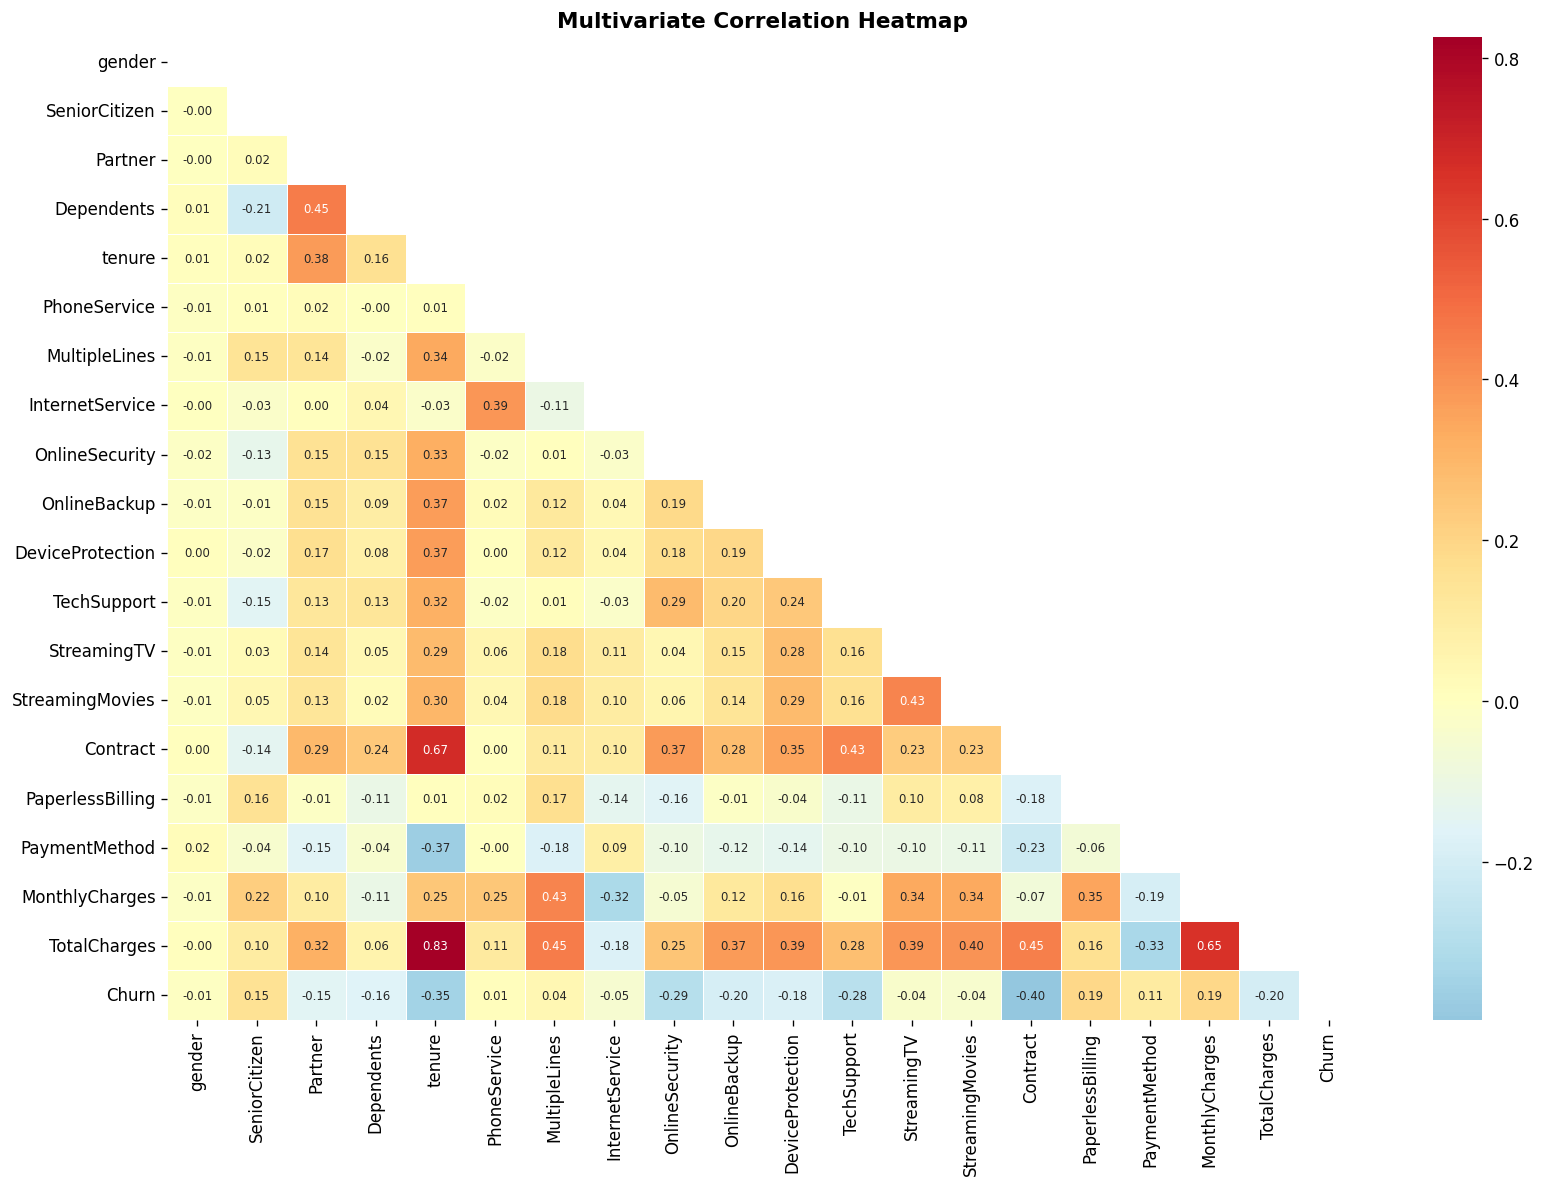

In [12]:
print("\n" + "─" * 50)
print("  2.3 MULTIVARIATE ANALYSIS")
print("─" * 50)

# --- Correlation heatmap (numerical + encoded) ---
corr_matrix = df_mi.copy()
corr_matrix["Churn"] = df["Churn_binary"]
corr = corr_matrix.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Multivariate Correlation Heatmap", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("plots/07_correlation_heatmap.png", bbox_inches="tight")
plt.show()

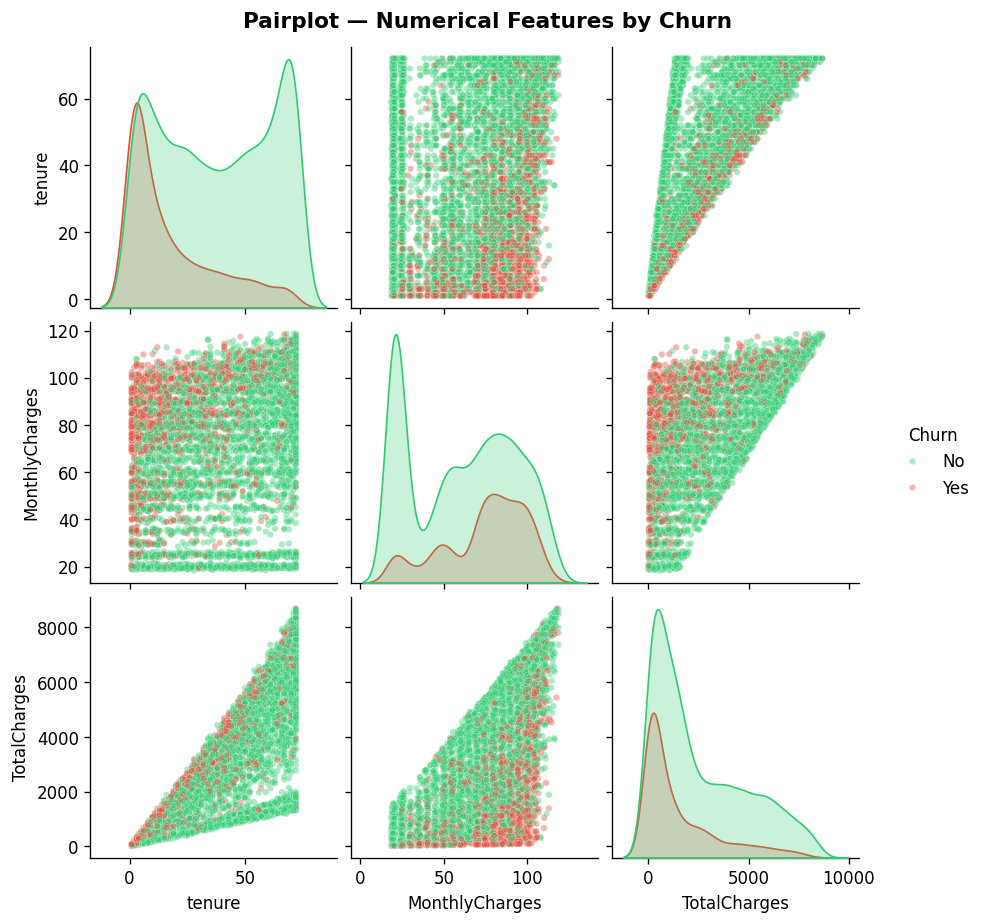

In [13]:
# Pairplot (key numeric features)
pairplot_df = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].dropna()
pairplot_df["TotalCharges"] = pd.to_numeric(pairplot_df["TotalCharges"], errors="coerce")
g = sns.pairplot(pairplot_df, hue="Churn", palette={"No": COLORS["retain"], "Yes": COLORS["churn"]},
                 diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
g.fig.suptitle("Pairplot — Numerical Features by Churn", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("plots/08_pairplot.png", bbox_inches="tight")
plt.show()

### DATA PREPARATION

##### Step 1: Fix TotalCharges 

In [14]:
print("\n" + "─" * 50)
print("  DATA PREPARATION (Pre-Treatment)")
print("─" * 50)

df_clean = df_raw.copy()

# Step 1: Fix TotalCharges (mixed type)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
print(f"\n[Step 1] TotalCharges — Missing after coercion: {df_clean['TotalCharges'].isna().sum()}")


──────────────────────────────────────────────────
  DATA PREPARATION (Pre-Treatment)
──────────────────────────────────────────────────

[Step 1] TotalCharges — Missing after coercion: 11


##### Step 2: Outlier Detection

In [15]:
#Step 2: Outlier Detection (IQR method -> treat as missing)
print("\nStep 2 :Outlier Detection & Treatment")
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"  {col}: {outliers} outliers found (bounds [{lower:.1f}, {upper:.1f}])")
    df_clean.loc[(df_clean[col] < lower) | (df_clean[col] > upper), col] = np.nan



Step 2 :Outlier Detection & Treatment
  tenure: 0 outliers found (bounds [-60.0, 124.0])
  MonthlyCharges: 0 outliers found (bounds [-46.0, 171.4])
  TotalCharges: 0 outliers found (bounds [-4688.5, 8884.7])


##### Step 3: Missing Values

In [16]:
#Step 3: Missing Values
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
print(f"\nStep 3: Missing Values after outlier treatment:\n{missing}")
# Impute numeric with median
for col in num_cols:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"  {col} -> filled with median ({median_val:.2f})")



Step 3: Missing Values after outlier treatment:
TotalCharges    11
dtype: int64
  tenure -> filled with median (29.00)
  MonthlyCharges -> filled with median (70.35)
  TotalCharges -> filled with median (1397.47)


In [17]:
if "customerID" in df_clean.columns:
    df_clean.drop(columns=["customerID"], inplace=True)

##### Step 5: Encode Target

In [18]:
# ── Step 5: Encode Target ──
# Guard against re-running: only encode if Churn is still a string
if df_clean["Churn"].dtype == object:
    df_clean["Churn"] = (df_clean["Churn"] == "Yes").astype(int)
    print("[Step 5] Churn encoded: Yes=1, No=0")
else:
    print("[Step 5] Churn already encoded — skipping")

[Step 5] Churn encoded: Yes=1, No=0


##### Step 6: Feature Engineering

In [19]:
#Step 6: Feature Engineering
print("\nStep 6: Feature Engineering")
df_clean["AvgMonthlyCharge"]    = df_clean["TotalCharges"] / (df_clean["tenure"] + 1)
df_clean["TenureGroup"]         = pd.cut(df_clean["tenure"], bins=[0,12,24,48,72],
                                          labels=["0-1yr","1-2yr","2-4yr","4+yr"])
df_clean["HasStreamingService"] = ((df_clean["StreamingTV"] == "Yes") |
                                   (df_clean["StreamingMovies"] == "Yes")).astype(int)
df_clean["NumServices"]         = (df_clean[["PhoneService","OnlineSecurity","OnlineBackup",
                                              "DeviceProtection","TechSupport",
                                              "StreamingTV","StreamingMovies"]] == "Yes").sum(axis=1)
print("  + AvgMonthlyCharge, TenureGroup, HasStreamingService, NumServices")



Step 6: Feature Engineering
  + AvgMonthlyCharge, TenureGroup, HasStreamingService, NumServices


##### Step 7: Encoding

In [20]:

# ── Step 7: Encoding ──
print("\n[Step 7] Encoding Categorical Variables")
binary_map = {"Yes": 1, "No": 0, "Male": 1, "Female": 0}
binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling",
               "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
               "StreamingTV","StreamingMovies"]
for col in binary_cols:
    df_clean[col] = df_clean[col].map(binary_map).fillna(df_clean[col])



[Step 7] Encoding Categorical Variables


In [21]:
# One-hot encode multi-class categoricals
# Only encode columns that still exist and are still categorical/object
ohe_cols = ["MultipleLines", "InternetService", "Contract", "PaymentMethod", "TenureGroup"]
ohe_cols_present = [c for c in ohe_cols if c in df_clean.columns]
if ohe_cols_present:
    df_clean = pd.get_dummies(df_clean, columns=ohe_cols_present, drop_first=False)
    print(f"  One-hot encoded: {ohe_cols_present}")
else:
    print("  [SKIP] OHE columns already encoded from a previous run")
print(f"  Shape after encoding: {df_clean.shape}")

  One-hot encoded: ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod', 'TenureGroup']
  Shape after encoding: (7043, 36)


##### Step 8: Scaling

In [22]:
# Step 8: Scaling
print("\nStep 8: Feature Scaling (StandardScaler on numerics)")
X = df_clean.drop(columns=["Churn"])
#y = df_clean["Churn"]
# Convert all columns to numeric
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"\nFinal Feature Matrix: {X_scaled.shape}")
#print(f"Class Distribution:\n{y.value_counts()}")



Step 8: Feature Scaling (StandardScaler on numerics)

Final Feature Matrix: (7043, 35)


In [23]:
# ── Re-extract y safely before split ──
# Handles both cases: Churn is still string OR already 0/1 integer
if df_clean["Churn"].dtype == object:
    y = (df_clean["Churn"] == "Yes").astype(int)
else:
    y = df_clean["Churn"].astype(int)

# Sanity check — must show both classes
print("Class distribution in y:", y.value_counts().to_dict())
assert y.nunique() == 2, "ERROR: y still has only 1 class"


Class distribution in y: {0: 5174, 1: 1869}


##### Step 9: Train/Test Split + SMOTE


[Train/Test Split] Train: (8278, 35), Test: (1409, 35)
[SMOTE] Balanced training set: {0: 4139, 1: 4139}


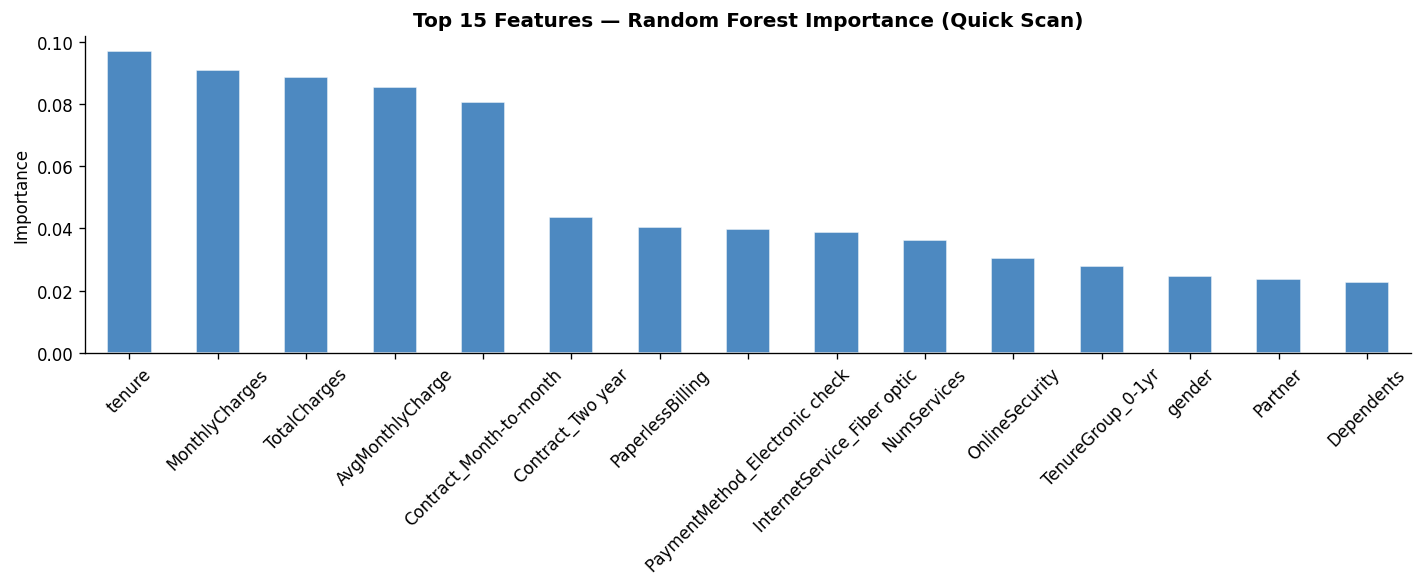


[Feature Selection] Kept top 20 features: 20


In [24]:
# ── Step 9: Train/Test Split + SMOTE ──
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\n[Train/Test Split] Train: {X_train_bal.shape}, Test: {X_test.shape}")
print(f"[SMOTE] Balanced training set: {pd.Series(y_train_bal).value_counts().to_dict()}")

# ── Feature Importance Snapshot (before modeling) ──
rf_quick = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)
rf_quick.fit(X_train_bal, y_train_bal)
feat_imp = pd.Series(rf_quick.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
feat_imp.head(15).plot(kind="bar", ax=ax, color=COLORS["primary"], edgecolor="white", alpha=0.85)
ax.set_title("Top 15 Features — Random Forest Importance (Quick Scan)", fontweight="bold")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("plots/09_feature_importance.png", bbox_inches="tight")
plt.show()
# Select top-20 features to reduce dimensionality
top_features = feat_imp.head(20).index.tolist()
X_train_sel = X_train_bal[top_features]
X_test_sel  = X_test[top_features]
print(f"\n[Feature Selection] Kept top 20 features: {len(top_features)}")


# CHAPTER 3 : MODELING

In [25]:
# Helper function
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else y_pred
    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_te, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_te, y_pred, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(y_te, y_prob), 4),
        "Train Time": round(train_time, 2),
        "_y_pred": y_pred,
        "_y_prob": y_prob,
    }

### 3.1  ML models :

#### M1: Logistic Regression

In [26]:
#M1: Logistic Regression 
print("\n[ML-1] Logistic Regression")
lr_params = {"C": 1.0, "max_iter": 1000, "solver": "lbfgs", "random_state": RANDOM_STATE}
ml1 = LogisticRegression(**lr_params)
r_ml1 = evaluate_model("Logistic Regression", ml1, X_train_sel, y_train_bal, X_test_sel, y_test)
print(f"  Accuracy: {r_ml1['Accuracy']} | F1: {r_ml1['F1']} | ROC-AUC: {r_ml1['ROC-AUC']}")


[ML-1] Logistic Regression
  Accuracy: 0.7353 | F1: 0.6135 | ROC-AUC: 0.8395


#### M2: Random Forestt

In [27]:
#M2: Random Forestt
print("[ML-2] Random Forest")
rf_params = {"n_estimators": 200, "max_depth": 10, "min_samples_split": 5,
             "min_samples_leaf": 2, "random_state": RANDOM_STATE, "n_jobs": -1}
ml2 = RandomForestClassifier(**rf_params)
r_ml2 = evaluate_model("Random Forest", ml2, X_train_sel, y_train_bal, X_test_sel, y_test)
print(f"  Accuracy: {r_ml2['Accuracy']} | F1: {r_ml2['F1']} | ROC-AUC: {r_ml2['ROC-AUC']}")


[ML-2] Random Forest
  Accuracy: 0.7686 | F1: 0.6119 | ROC-AUC: 0.8384


#### M3: XGBoost

In [28]:
#M3: XGBoost
print("[ML-3] XGBoost")
xgb_params = {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05,
              "subsample": 0.8, "colsample_bytree": 0.8,
              "use_label_encoder": False, "eval_metric": "logloss",
              "random_state": RANDOM_STATE}
ml3 = XGBClassifier(**xgb_params)
r_ml3 = evaluate_model("XGBoost", ml3, X_train_sel, y_train_bal, X_test_sel, y_test)
print(f"  Accuracy: {r_ml3['Accuracy']} | F1: {r_ml3['F1']} | ROC-AUC: {r_ml3['ROC-AUC']}")


[ML-3] XGBoost
  Accuracy: 0.7764 | F1: 0.5946 | ROC-AUC: 0.8386


In [29]:
#ML Results Table
ml_results = pd.DataFrame([r_ml1, r_ml2, r_ml3]).drop(columns=["_y_pred", "_y_prob"])
print("\nML comparative results:")
print(ml_results.to_string(index=False))
ml_results.to_csv("results/ml_results.csv", index=False)



ML comparative results:
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  Train Time
Logistic Regression    0.7353     0.5008  0.7914 0.6135   0.8395        0.22
      Random Forest    0.7686     0.5515  0.6872 0.6119   0.8384        2.68
            XGBoost    0.7764     0.5732  0.6176 0.5946   0.8386        4.03


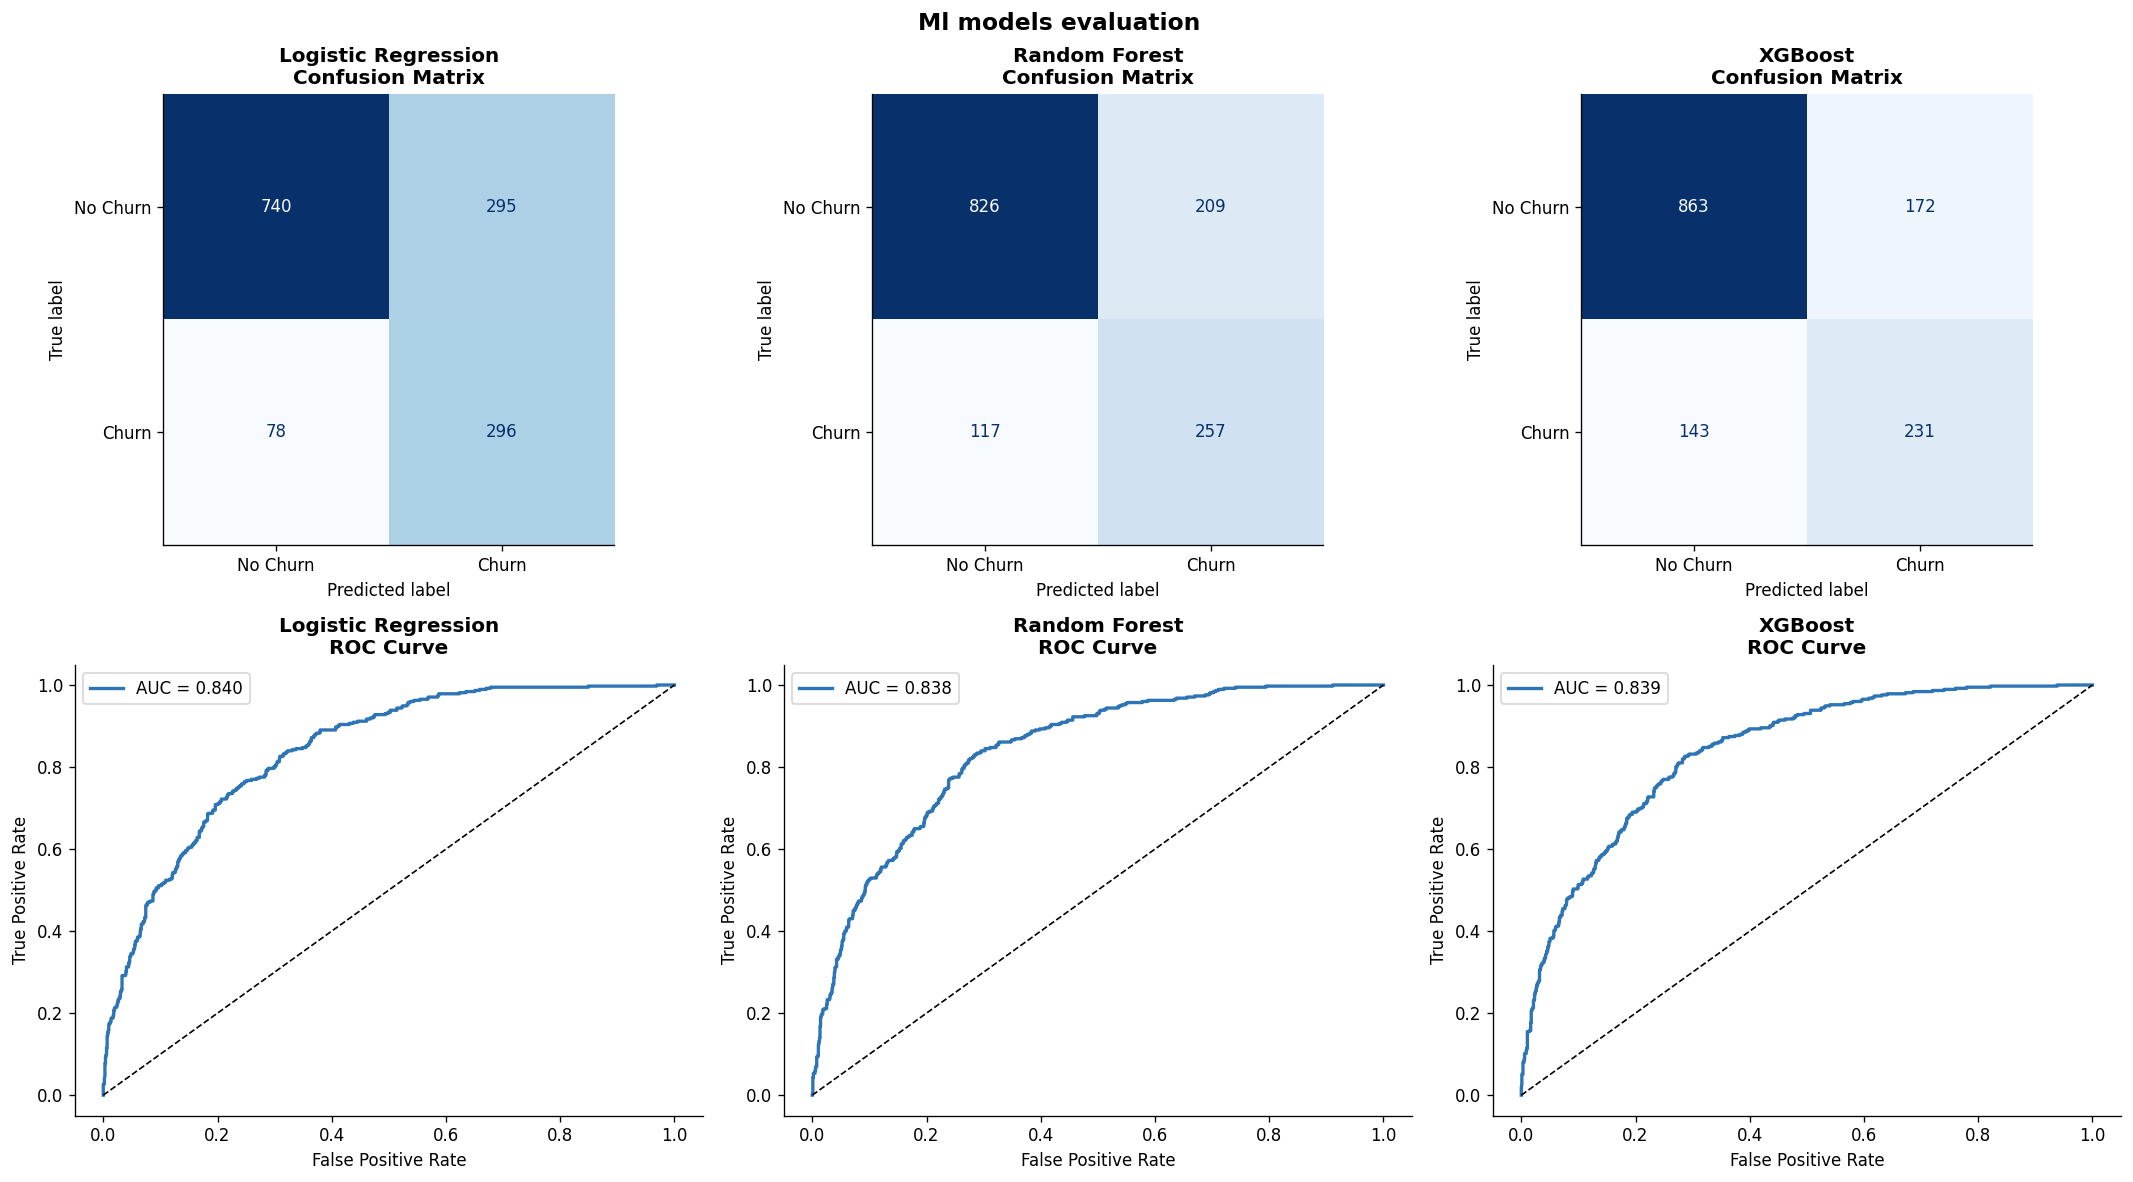

In [30]:
#Confusion Matrices + ROC for ML
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ml_pairs = [("Logistic Regression", r_ml1), ("Random Forest", r_ml2), ("XGBoost", r_ml3)]
models_list = [ml1, ml2, ml3]

for i, (name, res) in enumerate(ml_pairs):
    # Confusion matrix
    cm = confusion_matrix(y_test, res["_y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=axes[0, i], colorbar=False, cmap="Blues")
    axes[0, i].set_title(f"{name}\nConfusion Matrix", fontweight="bold")
    # ROC
    fpr, tpr, _ = roc_curve(y_test, res["_y_prob"])
    axes[1, i].plot(fpr, tpr, color=COLORS["primary"], lw=2,
                    label=f"AUC = {res['ROC-AUC']:.3f}")
    axes[1, i].plot([0, 1], [0, 1], "k--", lw=1)
    axes[1, i].set_title(f"{name}\nROC Curve", fontweight="bold")
    axes[1, i].set_xlabel("False Positive Rate")
    axes[1, i].set_ylabel("True Positive Rate")
    axes[1, i].legend()

plt.suptitle("Ml models evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/10_ml_evaluation.png", bbox_inches="tight")
plt.show()

### ML Bar Chart

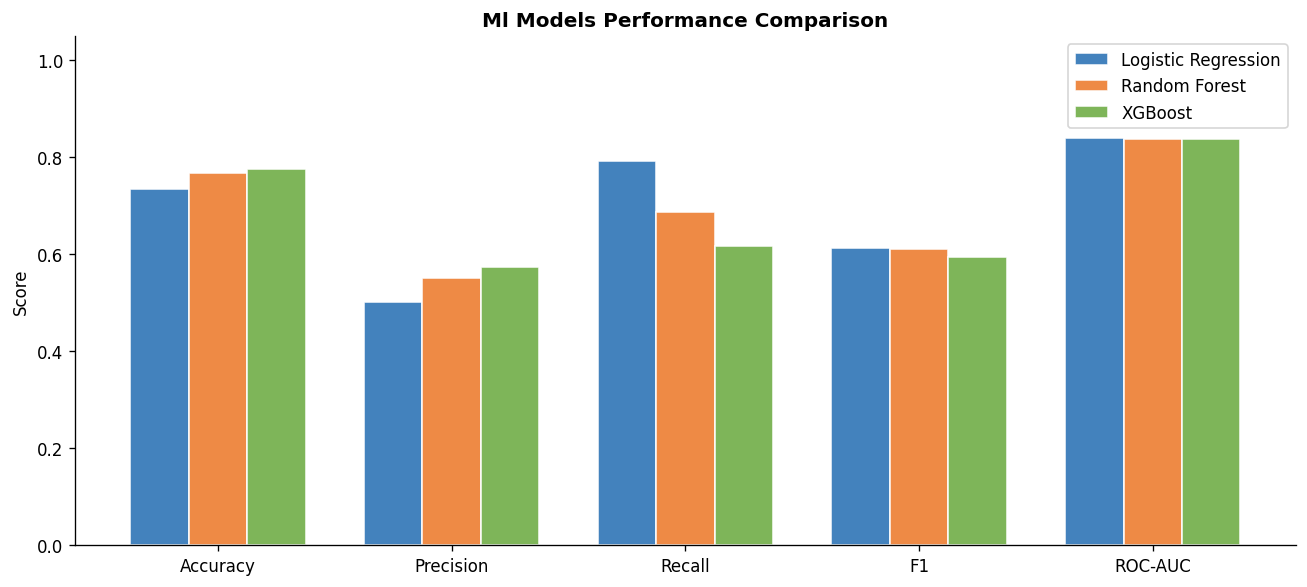

In [31]:
#ML Bar Chart
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
ml_bar_df = ml_results.set_index("Model")[metrics]
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metrics))
w = 0.25
for j, (idx, row) in enumerate(ml_bar_df.iterrows()):
    ax.bar(x + j * w, row.values, w, label=idx,
           color=[COLORS["primary"], COLORS["secondary"], COLORS["success"]][j],
           edgecolor="white", alpha=0.9)
ax.set_xticks(x + w)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Ml Models Performance Comparison", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plots/11_ml_comparison.png", bbox_inches="tight")
plt.show()

### 3.2  artificial neural network models

In [32]:
X_train_np = X_train_sel.values.astype(np.float32)
X_test_np  = X_test_sel.values.astype(np.float32)
y_train_np = y_train_bal.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=0),
]


### ANN1: Shallow Network (Baseline)

In [33]:
# ANN1: Shallow Network (Baseline)
print("\nANN-1: Shallow Network — 1 hidden layer")
ann1 = keras.Sequential([
    layers.Input(shape=(X_train_np.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
], name="ANN_Shallow")
ann1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
             loss="binary_crossentropy", metrics=["accuracy"])
ann1.summary()
h1_ann = ann1.fit(X_train_np, y_train_np, validation_split=0.15,
                  epochs=100, batch_size=64, callbacks=callbacks, verbose=0)
print(f"  Trained for {len(h1_ann.history['loss'])} epochs")


ANN-1: Shallow Network — 1 hidden layer


Model: "ANN_Shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 128 (512.00 B)

  Trained for 66 epochs


### ANN2: Deep Network with Dropout

In [34]:
#ANN2: Deep Network with Dropout
print("[ANN-2] Deep Network — 3 hidden layers with Dropout & BatchNorm")
ann2 = keras.Sequential([
    layers.Input(shape=(X_train_np.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
], name="ANN_Deep")
ann2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
             loss="binary_crossentropy", metrics=["accuracy"])
ann2.summary()
h2_ann = ann2.fit(X_train_np, y_train_np, validation_split=0.15,
                  epochs=150, batch_size=32, callbacks=callbacks, verbose=0)
print(f"  Trained for {len(h2_ann.history['loss'])} epochs")

[ANN-2] Deep Network — 3 hidden layers with Dropout & BatchNorm


Model: "ANN_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 448 (1.75 KB)

  Trained for 10 epochs


### ANN3: Wider Network with L2 Regularisation

In [35]:
#ANN3: Wider Network with L2 Regularisation
print("[ANN-3] Wide Network — 2 hidden layers with L2 Regularisation")
ann3 = keras.Sequential([
    layers.Input(shape=(X_train_np.shape[1],)),
    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
], name="ANN_Wide_L2")
ann3.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
             loss="binary_crossentropy", metrics=["accuracy"])
ann3.summary()
h3_ann = ann3.fit(X_train_np, y_train_np, validation_split=0.15,
                  epochs=150, batch_size=64, callbacks=callbacks, verbose=0)
print(f"  Trained for {len(h3_ann.history['loss'])} epochs")

[ANN-3] Wide Network — 2 hidden layers with L2 Regularisation


Model: "ANN_Wide_L2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 256)                 │           5,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,937 (156.00 KB)

 Trainable params: 39,169 (153.00 KB)

 Non-trainable params: 768 (3.00 KB)

  Trained for 10 epochs


### ANN Evaluation

In [36]:
# ── ANN Evaluation ──
def eval_ann(name, model, X_te, y_te):
    y_prob = model.predict(X_te, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_te, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_te, y_pred, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(y_te, y_prob), 4),
        "_y_pred": y_pred,
        "_y_prob": y_prob,
    }

r_ann1 = eval_ann("ANN Shallow (1HL)", ann1, X_test_np, y_test_np)
r_ann2 = eval_ann("ANN Deep (3HL)", ann2, X_test_np, y_test_np)
r_ann3 = eval_ann("ANN Wide+L2 (2HL)", ann3, X_test_np, y_test_np)

ann_results = pd.DataFrame([r_ann1, r_ann2, r_ann3]).drop(columns=["_y_pred", "_y_prob"])
print("\n### ANN COMPARATIVE RESULTS ###")
print(ann_results.to_string(index=False))
ann_results.to_csv("results/ann_results.csv", index=False)


### ANN COMPARATIVE RESULTS ###
            Model  Accuracy  Precision  Recall     F1  ROC-AUC
ANN Shallow (1HL)    0.7686     0.5548  0.6497 0.5985   0.8335
   ANN Deep (3HL)    0.7480     0.5183  0.7193 0.6025   0.8242
ANN Wide+L2 (2HL)    0.7743     0.5729  0.5882 0.5805   0.8220


### ANN Training Curves

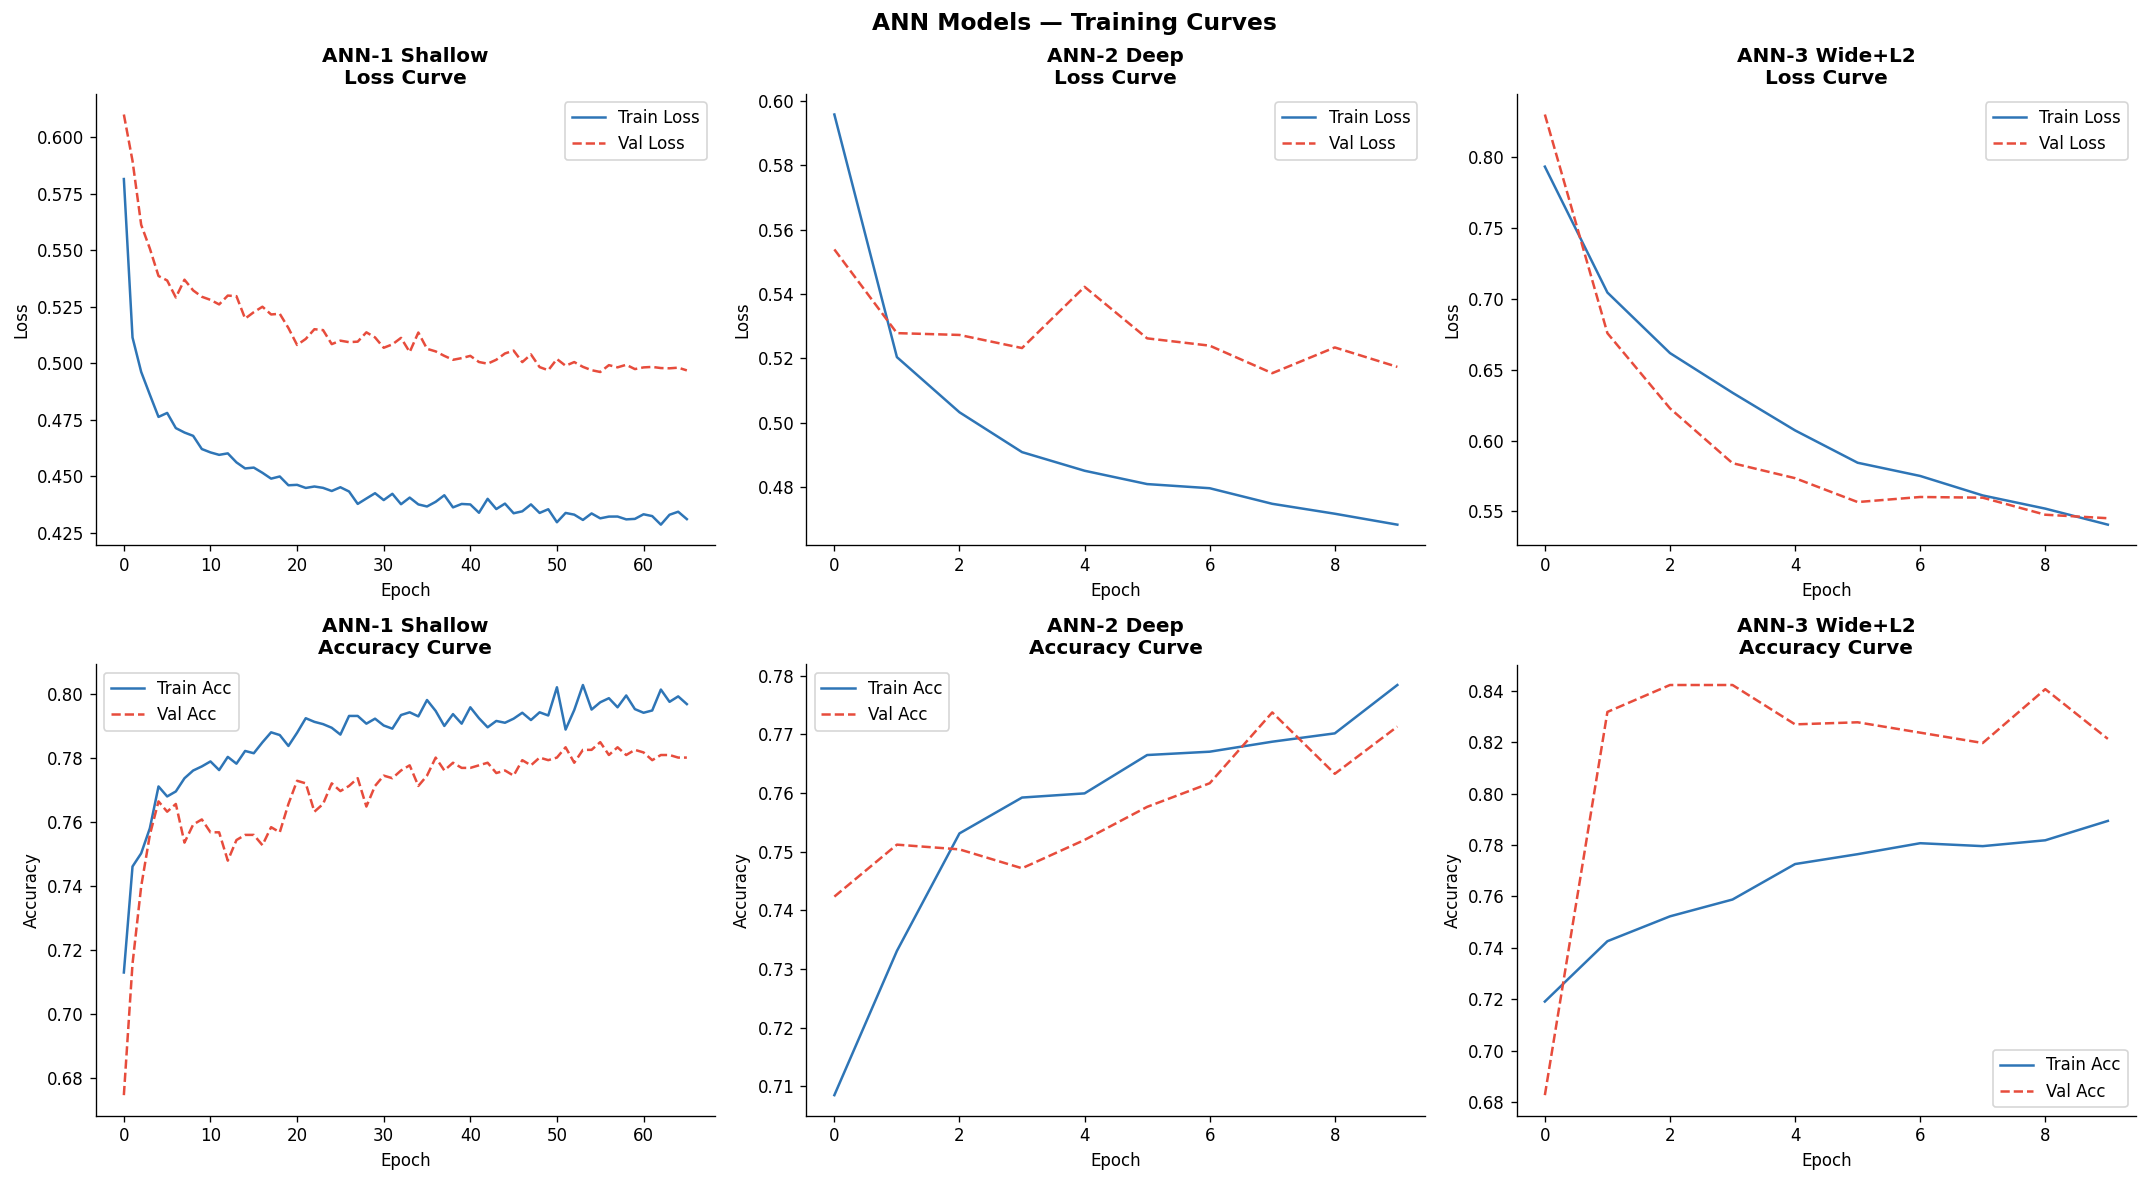

In [38]:
# ── ANN Training Curves ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ann_hist  = [h1_ann, h2_ann, h3_ann]
ann_names = ["ANN-1 Shallow", "ANN-2 Deep", "ANN-3 Wide+L2"]
for i, (h, name) in enumerate(zip(ann_hist, ann_names)):
    # Loss
    axes[0, i].plot(h.history["loss"], color=COLORS["primary"], label="Train Loss")
    axes[0, i].plot(h.history["val_loss"], color=COLORS["churn"], label="Val Loss", linestyle="--")
    axes[0, i].set_title(f"{name}\nLoss Curve", fontweight="bold")
    axes[0, i].set_xlabel("Epoch"); axes[0, i].set_ylabel("Loss")
    axes[0, i].legend()
    # Accuracy
    axes[1, i].plot(h.history["accuracy"], color=COLORS["primary"], label="Train Acc")
    axes[1, i].plot(h.history["val_accuracy"], color=COLORS["churn"], label="Val Acc", linestyle="--")
    axes[1, i].set_title(f"{name}\nAccuracy Curve", fontweight="bold")
    axes[1, i].set_xlabel("Epoch"); axes[1, i].set_ylabel("Accuracy")
    axes[1, i].legend()
plt.suptitle("ANN Models — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/12_ann_training_curves.png", bbox_inches="tight")
plt.show()

### ANN Confusion + ROC

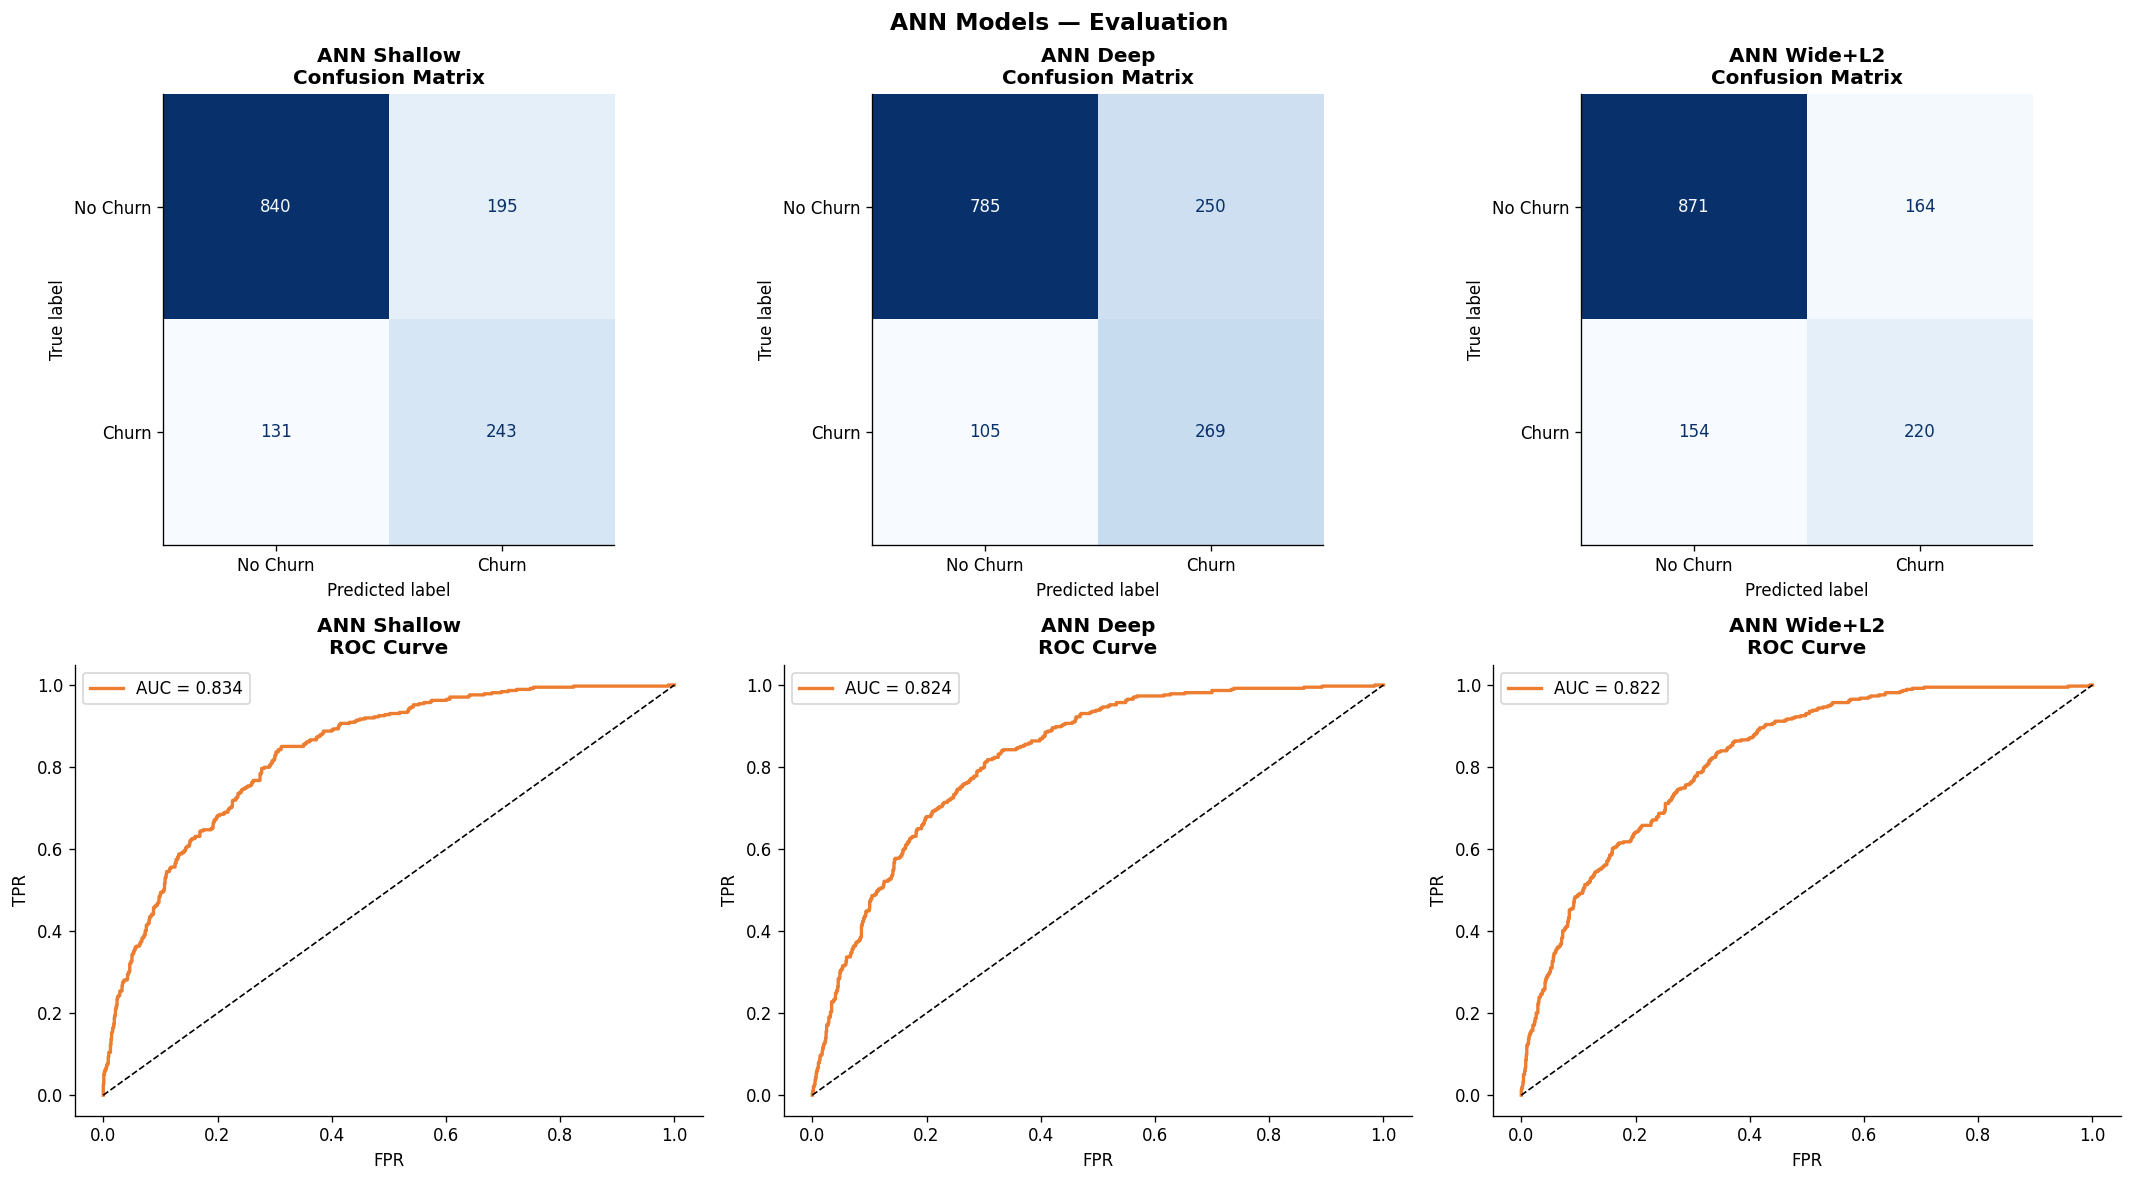

In [39]:
# ── ANN Confusion + ROC ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ann_pairs = [("ANN Shallow", r_ann1), ("ANN Deep", r_ann2), ("ANN Wide+L2", r_ann3)]
for i, (name, res) in enumerate(ann_pairs):
    cm = confusion_matrix(y_test_np, res["_y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=axes[0, i], colorbar=False, cmap="Blues")
    axes[0, i].set_title(f"{name}\nConfusion Matrix", fontweight="bold")
    fpr, tpr, _ = roc_curve(y_test_np, res["_y_prob"])
    axes[1, i].plot(fpr, tpr, color=COLORS["secondary"], lw=2, label=f"AUC = {res['ROC-AUC']:.3f}")
    axes[1, i].plot([0, 1], [0, 1], "k--", lw=1)
    axes[1, i].set_title(f"{name}\nROC Curve", fontweight="bold")
    axes[1, i].set_xlabel("FPR"); axes[1, i].set_ylabel("TPR")
    axes[1, i].legend()
plt.suptitle("ANN Models — Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/13_ann_evaluation.png", bbox_inches="tight")
plt.show()

### ANN Bar Comparison

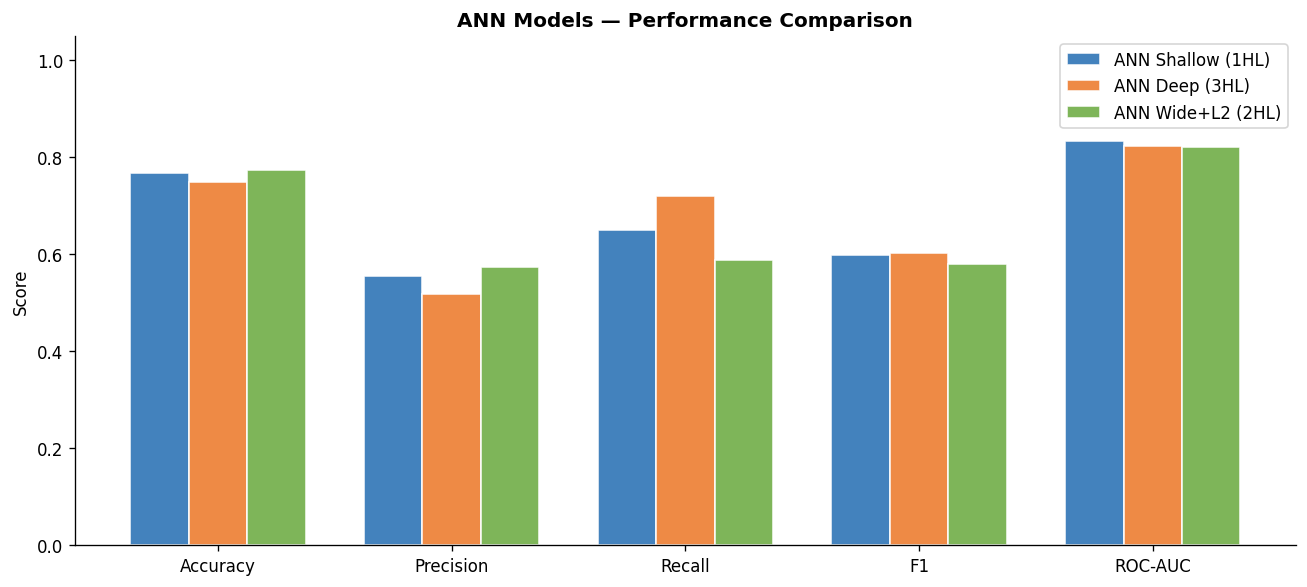

In [40]:
# ── ANN Bar Comparison ──
ann_bar_df = ann_results.set_index("Model")[metrics]
fig, ax = plt.subplots(figsize=(11, 5))
for j, (idx, row) in enumerate(ann_bar_df.iterrows()):
    ax.bar(x + j * w, row.values, w, label=idx,
           color=[COLORS["primary"], COLORS["secondary"], COLORS["success"]][j],
           edgecolor="white", alpha=0.9)
ax.set_xticks(x + w)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("ANN Models — Performance Comparison", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plots/14_ann_comparison.png", bbox_inches="tight")
plt.show()

### 3.3  FINAL COMPARISON ML vs ANN


──────────────────────────────────────────────────
  3.3 FINAL COMPARISON — ML vs ANN (All 6 Models)
──────────────────────────────────────────────────

### ALL MODELS — PERFORMANCE SUMMARY ###
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  Train Time Type
Logistic Regression    0.7353     0.5008  0.7914 0.6135   0.8395        0.22   ML
      Random Forest    0.7686     0.5515  0.6872 0.6119   0.8384        2.68   ML
            XGBoost    0.7764     0.5732  0.6176 0.5946   0.8386        4.03   ML
  ANN Shallow (1HL)    0.7686     0.5548  0.6497 0.5985   0.8335         NaN  ANN
     ANN Deep (3HL)    0.7480     0.5183  0.7193 0.6025   0.8242         NaN  ANN
  ANN Wide+L2 (2HL)    0.7743     0.5729  0.5882 0.5805   0.8220         NaN  ANN


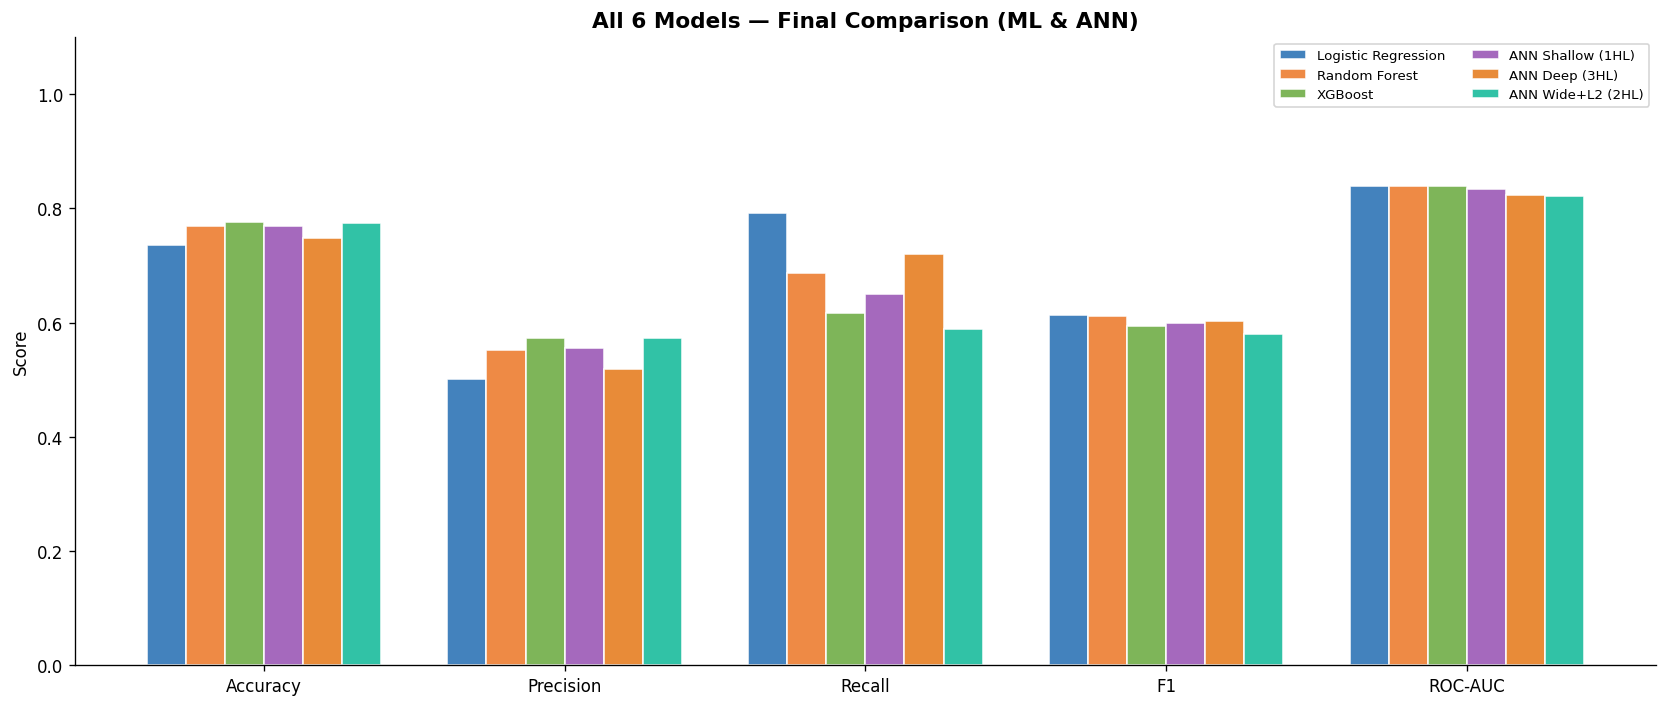

In [41]:
print("\n" + "─" * 50)
print("  3.3 FINAL COMPARISON — ML vs ANN (All 6 Models)")
print("─" * 50)

all_results = pd.DataFrame([r_ml1, r_ml2, r_ml3, r_ann1, r_ann2, r_ann3]
                           ).drop(columns=["_y_pred", "_y_prob"])
all_results["Type"] = ["ML", "ML", "ML", "ANN", "ANN", "ANN"]
print("\n### ALL MODELS — PERFORMANCE SUMMARY ###")
print(all_results.to_string(index=False))
all_results.to_csv("results/all_models_results.csv", index=False)

# ── Radar / Summary Bar ──
fig, ax = plt.subplots(figsize=(14, 6))
colors_all = [COLORS["primary"], COLORS["secondary"], COLORS["success"],
              "#9B59B6", "#E67E22", "#1ABC9C"]
for j, (_, row) in enumerate(all_results.iterrows()):
    bars = ax.bar(x + j * 0.13, all_results[metrics].iloc[j].values, 0.13,
                  label=row["Model"], color=colors_all[j], edgecolor="white", alpha=0.9)
ax.set_xticks(x + 0.13 * 2.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("All 6 Models — Final Comparison (ML & ANN)", fontweight="bold", fontsize=13)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("plots/15_final_comparison.png", bbox_inches="tight")
plt.show()

### Best Model Summary

In [43]:
best_idx = all_results["F1"].idxmax()
best = all_results.iloc[best_idx]
print(f"\nBEST MODEL : {best['Model']}")
print(f"   Accuracy : {best['Accuracy']}")
print(f"   Precision: {best['Precision']}")
print(f"   Recall   : {best['Recall']}")
print(f"   F1 Score : {best['F1']}")
print(f"   ROC-AUC  : {best['ROC-AUC']}")


BEST MODEL : Logistic Regression
   Accuracy : 0.7353
   Precision: 0.5008
   Recall   : 0.7914
   F1 Score : 0.6135
   ROC-AUC  : 0.8395
